{'par': 'genProfile', 'val': 'c:\\Users\\e.kim\\Desktop\\simS_sclc\\NNtraining_simss\\SIMsalabim\\Data\\SIM_45mA_0OD_d250nm.txt'}
{'par': 'genProfile', 'val': 'c:\\Users\\e.kim\\Desktop\\simS_sclc\\NNtraining_simss\\SIMsalabim\\Data\\SIM_45mA_0OD_d250nm.txt'}
{'par': 'genProfile', 'val': 'SIM_45mA_0OD_d250nm.txt'}
{'par': 'genProfile', 'val': 'SIM_45mA_0OD_d250nm.txt'}
{'par': 'genProfile', 'val': 'SIM_45mA_0OD_d250nm.txt'}
{'par': 'genProfile', 'val': 'SIM_45mA_0OD_d250nm.txt'}


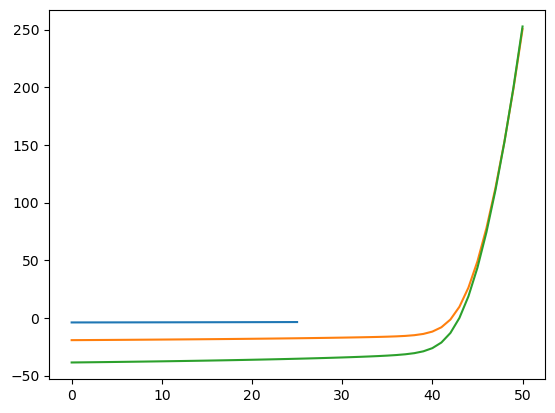

In [4]:
from simss_utils.JV_steady_state import *
import matplotlib.pyplot as plt

cwd = os.getcwd()

simss_device_parameters = os.path.join(cwd, 'SIMsalabim','SimSS','simulation_setup.txt')     
session_path = os.path.join(os.getcwd(), 'SIMsalabim','SimSS')
JV_file_name = os.path.join(session_path,'JV.dat')
# Create the results directory if it doesn't exist
dataset_name = "test_jvi"
res_dir = os.path.join(cwd, "Datagen_results", dataset_name)
genprofile_path = os.path.join(cwd, 'SIMsalabim', 'Data', 'SIM_45mA_0OD_d250nm.txt')

W_L, W_R, E_d_sh, N_t_sh, N_t_d, mu_e = 4.2, 5.35, 4.6, 5e+22, 1e+21, 1e-7
ID = str(uuid.uuid4())
dum_str = f'_{ID}'

# Use a unique trap filename per process to avoid collisions
trap_fn = os.path.join(cwd, 'SIMsalabim', 'SimSS', f"traps0.txt")
# JV_file_name_base, JV_file_name_ext = os.path.splitext(JV_file_name)
# JV_file_name = os.path.join(res_dir,'JV'+dum_str+'.dat')
# logFile = os.path.join(res_dir,'log'+dum_str+'.txt')

# Create trap file
with open(trap_fn, 'w') as f:
    f.write(f"E\tNtrap\n{E_d_sh}\t{N_t_sh}\n4.8\t{N_t_d}")

cmd_pars = [
        # {'par':'dev_par_file','val':simss_device_parameters},
        # {'par':'JVFile','val':JV_file_name},
        # {'par':'logFile','val':logFile},
        {'par': 'W_L', 'val': str(W_L)}, 
        {'par': 'W_R', 'val': str(W_R)},
        {'par': 'l1.bulkTrapFile', 'val': trap_fn},
        {'par': 'l1.mu_n', 'val': str(mu_e)},
        # {'par': 'G_frac', 'val': str(0.1)},
        {'par': 'genProfile', 'val': genprofile_path}
    ]

try: 
    run_mode = True
    G_fracs = [0.1,0.5,1]
    
    # result, message = utils_gen.run_simulation('simss', cmd_pars, session_path, run_mode, verbose=True)
    # print(result)
    # print(message)
    res = run_SS_JV(simss_device_parameters,res_dir,
                    session_path,JV_file_name,G_fracs,parallel=True,force_multithreading=False,cmd_pars=cmd_pars, UUID=ID)
        
except Exception as e:
    print(f"CRASH at ID {ID}: Parameters: {cmd_pars}")
    print(f"Error Details: {e}")

for G_frac in G_fracs:  
    jv_path = os.path.join(res_dir, f'JV_Gfrac_{G_frac}_{ID}.dat')
    # log_path = os.path.join(res_dir, f'log_{ID}.dat')
    try:
        data = pd.read_csv(jv_path, sep=r'\s+')
        data_JV = data['Jext']
        plt.plot(data_JV)
    except (pd.errors.EmptyDataError, pd.errors.ParserError):
        data_JV = None

# Cleanup immediately after reading
# if os.path.exists(jv_path): os.remove(jv_path)
# if os.path.exists(log_path): os.remove(log_path)
# if os.path.exists(trap_fn): os.remove(trap_fn)